In [25]:
import os
import zipfile
import numpy as np
import random
import shutil

import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path.cwd().parent

RAW_DIR = BASE_DIR / "dataset" / "raw"
ESC50_DIR = BASE_DIR / "dataset" / "esc50"

RAW_DIR, ESC50_DIR

(WindowsPath('d:/CDAC PROJECT/2dnn/dataset/raw'),
 WindowsPath('d:/CDAC PROJECT/2dnn/dataset/esc50'))

In [4]:
list(ESC50_DIR.iterdir())[:10]

[WindowsPath('d:/CDAC PROJECT/2dnn/dataset/esc50/audio'),
 WindowsPath('d:/CDAC PROJECT/2dnn/dataset/esc50/bc_utils.py'),
 WindowsPath('d:/CDAC PROJECT/2dnn/dataset/esc50/esc50.csv'),
 WindowsPath('d:/CDAC PROJECT/2dnn/dataset/esc50/utils.py'),
 WindowsPath('d:/CDAC PROJECT/2dnn/dataset/esc50/utils2.py')]

In [5]:
import pandas as pd

csv_path = ESC50_DIR / "esc50.csv"

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()

Shape: (2000, 7)


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [6]:
df.columns

Index(['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take'], dtype='str')

In [10]:
wildlife_classes = [
    "frog",
    "crow",
    "crickets",
    "chirping_birds",
    "dog"
]

threat_classes = [
    "chainsaw",
    "siren",
    "engine",
    "helicopter"
]

selected_classes = wildlife_classes + threat_classes

forest_df = df[df["category"].isin(selected_classes)].copy()

forest_df["label"] = forest_df["category"].apply(
    lambda x: 0 if x in wildlife_classes else 1
)

forest_df.head()

,filename,fold,target,category,esc10,src_file,take,label
0,1-100032-A-0.wav,1,0,dog,True,100032,A,0
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,0
8,1-103298-A-9.wav,1,9,crow,False,103298,A,0
14,1-110389-A-0.wav,1,0,dog,True,110389,A,0
24,1-116765-A-41.wav,1,41,chainsaw,True,116765,A,1


In [11]:
forest_df["label"].value_counts()

label
0    200
1    160
Name: count, dtype: int64

In [12]:
forest_df.groupby(["category", "label"]).size()

category        label
chainsaw        1        40
chirping_birds  0        40
crickets        0        40
crow            0        40
dog             0        40
engine          1        40
frog            0        40
helicopter      1        40
siren           1        40
dtype: int64

In [19]:
print("Wildlife :", len(list(SAFE_DIR.glob("*.wav"))))
print("Threat   :", len(list(THREAT_DIR.glob("*.wav"))))

Wildlife : 200
Threat   : 160


In [20]:
forest_df["category"].value_counts()

category
dog               40
chirping_birds    40
crow              40
chainsaw          40
frog              40
helicopter        40
engine            40
siren             40
crickets          40
Name: count, dtype: int64

1-75162-A-9.wav


c:\Users\Priyansu\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


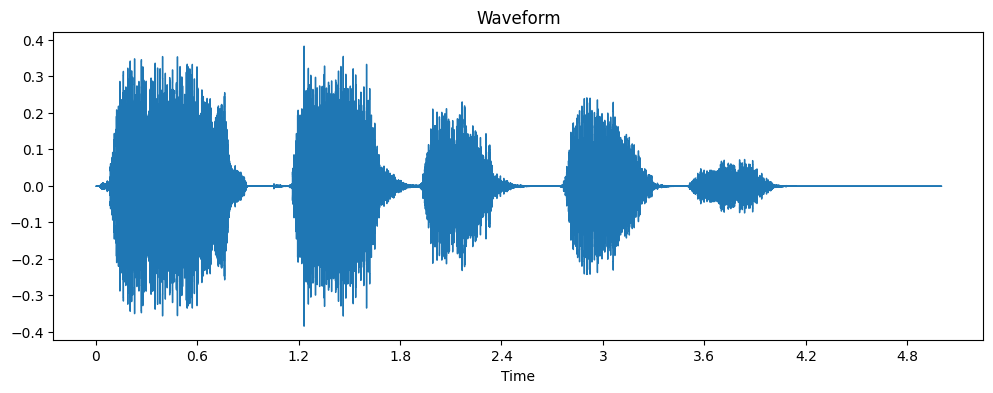

In [21]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random

sample_file = random.choice(list(SAFE_DIR.glob("*.wav")))

print(sample_file.name)

y, sr = librosa.load(sample_file, sr=22050)

plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.show()

In [24]:
sample_file = random.choice(list(SAFE_DIR.glob("*.wav")))

y, sr = librosa.load(sample_file, sr=22050)

mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128,
    fmax=8000
)

mel_spec_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

print(mel_spec_db.shape)

(128, 216)


In [27]:
TARGET_FRAMES = 216
SR = 22050
N_MELS = 128
FMAX = 8000

In [28]:
def extract_mel_spectrogram(file_path):

    y, sr = librosa.load(
        file_path,
        sr=SR
    )

    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=N_MELS,
        fmax=FMAX
    )

    mel_spec_db = librosa.power_to_db(
        mel_spec,
        ref=np.max
    )

    if mel_spec_db.shape[1] < TARGET_FRAMES:

        pad_width = TARGET_FRAMES - mel_spec_db.shape[1]

        mel_spec_db = np.pad(
            mel_spec_db,
            ((0,0),(0,pad_width)),
            mode="constant"
        )

    else:

        mel_spec_db = mel_spec_db[:, :TARGET_FRAMES]

    return mel_spec_db

In [29]:
x = extract_mel_spectrogram(sample_file)

print(x.shape)
print(x.min())
print(x.max())

(128, 216)
-80.0
0.0


In [30]:
all_files = []
all_labels = []

for f in SAFE_DIR.glob("*.wav"):
    all_files.append(f)
    all_labels.append(0)

for f in THREAT_DIR.glob("*.wav"):
    all_files.append(f)
    all_labels.append(1)

print(len(all_files))

360


In [34]:
from tqdm import tqdm

X = []
y = []

for file_path, label in tqdm(
    zip(all_files, all_labels),
    total=len(all_files)
):

    try:

        mel = extract_mel_spectrogram(file_path)

        X.append(mel)
        y.append(label)

    except Exception as e:

        print("Failed:", file_path.name)
        print(e)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

print(X.shape)
print(y.shape)

100%|██████████| 360/360 [00:11<00:00, 31.91it/s]


(360, 128, 216)
(360,)


In [35]:
PROCESSED_DIR = BASE_DIR / "dataset" / "processed"

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(PROCESSED_DIR)

d:\CDAC PROJECT\2dnn\dataset\processed


In [36]:
np.save(
    PROCESSED_DIR / "X.npy",
    X
)

np.save(
    PROCESSED_DIR / "y.npy",
    y
)

print("Saved")

Saved


In [37]:
X_loaded = np.load(
    PROCESSED_DIR / "X.npy"
)

y_loaded = np.load(
    PROCESSED_DIR / "y.npy"
)

print(X_loaded.shape)
print(y_loaded.shape)

(360, 128, 216)
(360,)


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_val.shape)

(288, 128, 216)
(72, 128, 216)


In [40]:
mean_val = np.mean(X_train)
std_val = np.std(X_train)

print(mean_val)
print(std_val)

-43.603725
18.599325


In [41]:
MODELS_DIR = BASE_DIR / "models"

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

np.savez(
    MODELS_DIR / "norm_stats.npz",
    mean=mean_val,
    std=std_val
)

print("norm_stats saved")

norm_stats saved


In [42]:
X_train = (
    X_train - mean_val
) / (
    std_val + 1e-8
)

X_val = (
    X_val - mean_val
) / (
    std_val + 1e-8
)

In [43]:
print(X_train.mean())
print(X_train.std())

1.1577528e-07
0.99999994


In [44]:
np.save(
    PROCESSED_DIR / "X_train.npy",
    X_train
)

np.save(
    PROCESSED_DIR / "X_val.npy",
    X_val
)

np.save(
    PROCESSED_DIR / "y_train.npy",
    y_train
)

np.save(
    PROCESSED_DIR / "y_val.npy",
    y_val
)

print("Training splits saved")

Training splits saved


In [45]:
print(X.shape)
print(y.shape)

(360, 128, 216)
(360,)


In [46]:
print(X_train.shape)
print(X_val.shape)

(288, 128, 216)
(72, 128, 216)


In [47]:
print(X_train.mean())
print(X_train.std())

1.1577528e-07
0.99999994


In [48]:
import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [49]:
class ForestDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.FloatTensor(X)
        self.X = self.X.unsqueeze(1)

        self.y = torch.LongTensor(y)

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [50]:
train_dataset = ForestDataset(
    X_train,
    y_train
)

val_dataset = ForestDataset(
    X_val,
    y_val
)

print(len(train_dataset))
print(len(val_dataset))

288
72


In [51]:
BATCH_SIZE = 16

In [52]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [53]:
X_batch, y_batch = next(
    iter(train_loader)
)

print(X_batch.shape)
print(y_batch.shape)

torch.Size([16, 1, 128, 216])
torch.Size([16])


In [54]:
class ForestGuardCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(256),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                2
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [55]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = ForestGuardCNN().to(device)

print(device)

cuda


In [56]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable:", trainable_params)
print("Total:", total_params)

Trainable: 421954
Total: 421954


In [57]:
criterion = nn.CrossEntropyLoss()

In [58]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3
)

In [59]:
EPOCHS = 25

best_val_acc = 0.0

best_model_path = (
    MODELS_DIR /
    "best_model.pth"
)

In [64]:
model

ForestGuardCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [66]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (
            preds == y_batch
        ).sum().item()

        total += y_batch.size(0)

    epoch_loss = (
        running_loss /
        len(loader)
    )

    epoch_acc = (
        100 * correct / total
    )

    return epoch_loss, epoch_acc

In [67]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)

            correct += (
                preds == y_batch
            ).sum().item()

            total += y_batch.size(0)

    val_loss = (
        running_loss /
        len(loader)
    )

    val_acc = (
        100 * correct / total
    )

    return val_loss, val_acc

In [68]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [69]:
from tqdm import tqdm

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print(
            f"Saved Best Model ({best_val_acc:.2f}%)"
        )

Epoch [1/25] Train Loss: 0.5943 Train Acc: 68.40% Val Loss: 0.5920 Val Acc: 73.61%
Saved Best Model (73.61%)
Epoch [2/25] Train Loss: 0.4328 Train Acc: 77.08% Val Loss: 0.6549 Val Acc: 69.44%
Epoch [3/25] Train Loss: 0.4157 Train Acc: 82.29% Val Loss: 0.3807 Val Acc: 80.56%
Saved Best Model (80.56%)
Epoch [4/25] Train Loss: 0.3368 Train Acc: 85.07% Val Loss: 0.5330 Val Acc: 76.39%
Epoch [5/25] Train Loss: 0.3056 Train Acc: 86.81% Val Loss: 0.3527 Val Acc: 80.56%
Epoch [6/25] Train Loss: 0.2620 Train Acc: 89.58% Val Loss: 0.5150 Val Acc: 76.39%
Epoch [7/25] Train Loss: 0.2942 Train Acc: 87.15% Val Loss: 0.3169 Val Acc: 86.11%
Saved Best Model (86.11%)
Epoch [8/25] Train Loss: 0.2729 Train Acc: 88.19% Val Loss: 0.6157 Val Acc: 75.00%
Epoch [9/25] Train Loss: 0.2427 Train Acc: 89.24% Val Loss: 1.0883 Val Acc: 79.17%
Epoch [10/25] Train Loss: 0.2531 Train Acc: 89.93% Val Loss: 0.2026 Val Acc: 94.44%
Saved Best Model (94.44%)
Epoch [11/25] Train Loss: 0.2250 Train Acc: 90.28% Val Loss: 0.29

In [70]:
print(best_model_path)
print(best_val_acc)

d:\CDAC PROJECT\2dnn\models\best_model.pth
97.22222222222223


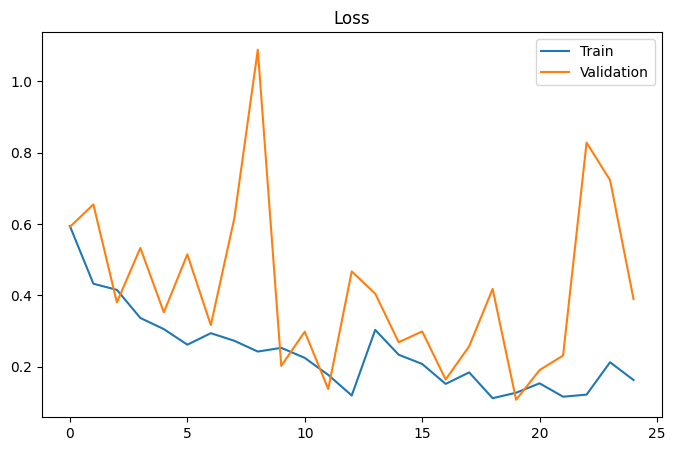

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.legend()

plt.title("Loss")

plt.show()

In [72]:
best_model = ForestGuardCNN()

best_model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

best_model.to(device)

best_model.eval()

ForestGuardCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [73]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

all_preds = []
all_labels = []

with torch.no_grad():

    for X_batch, y_batch in val_loader:

        X_batch = X_batch.to(device)

        outputs = best_model(X_batch)

        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            y_batch.numpy()
        )

In [74]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Wildlife",
            "Threat"
        ]
    )
)

              precision    recall  f1-score   support

    Wildlife       1.00      0.95      0.97        40
      Threat       0.94      1.00      0.97        32

    accuracy                           0.97        72
   macro avg       0.97      0.97      0.97        72
weighted avg       0.97      0.97      0.97        72



In [75]:
history = {
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_acc": train_accs,
    "val_acc": val_accs
}

import pickle

with open(
    MODELS_DIR / "history.pkl",
    "wb"
) as f:
    pickle.dump(history, f)

print("History Saved")

History Saved


In [76]:
label_map = {
    0: "Wildlife",
    1: "Threat"
}

import json

with open(
    MODELS_DIR / "label_map.json",
    "w"
) as f:

    json.dump(
        label_map,
        f,
        indent=4
    )

print("Label Map Saved")

Label Map Saved
